In [ ]:
pip install pyarrow

✅ Spark est prêt !
📊 Version Spark: 4.0.1
📦 Version Hadoop: 3.4.1

🔄 Chargement des données...
✅ Remontées mécaniques: 2910 lignes
✅ Données neige: 1976 stations

🔍 Structure des données:
Remontées mécaniques:
root
 |-- altitude_amont: string (nullable = true)
 |-- altitude_aval: string (nullable = true)
 |-- annee_construction: string (nullable = true)
 |-- annee_fin_service: string (nullable = true)
 |-- appareil: string (nullable = true)
 |-- banniere: string (nullable = true)
 |-- capacite: string (nullable = true)
 |-- constructeur: string (nullable = true)
 |-- coordonnees: struct (nullable = true)
 |    |-- amont: struct (nullable = true)
 |    |    |-- lat: double (nullable = true)
 |    |    |-- lng: double (nullable = true)
 |    |-- aval: struct (nullable = true)
 |    |    |-- lat: double (nullable = true)
 |    |    |-- lng: double (nullable = true)
 |-- debit: string (nullable = true)
 |-- denivelee: string (nullable = true)
 |-- departement: string (nullable = true)
 |--

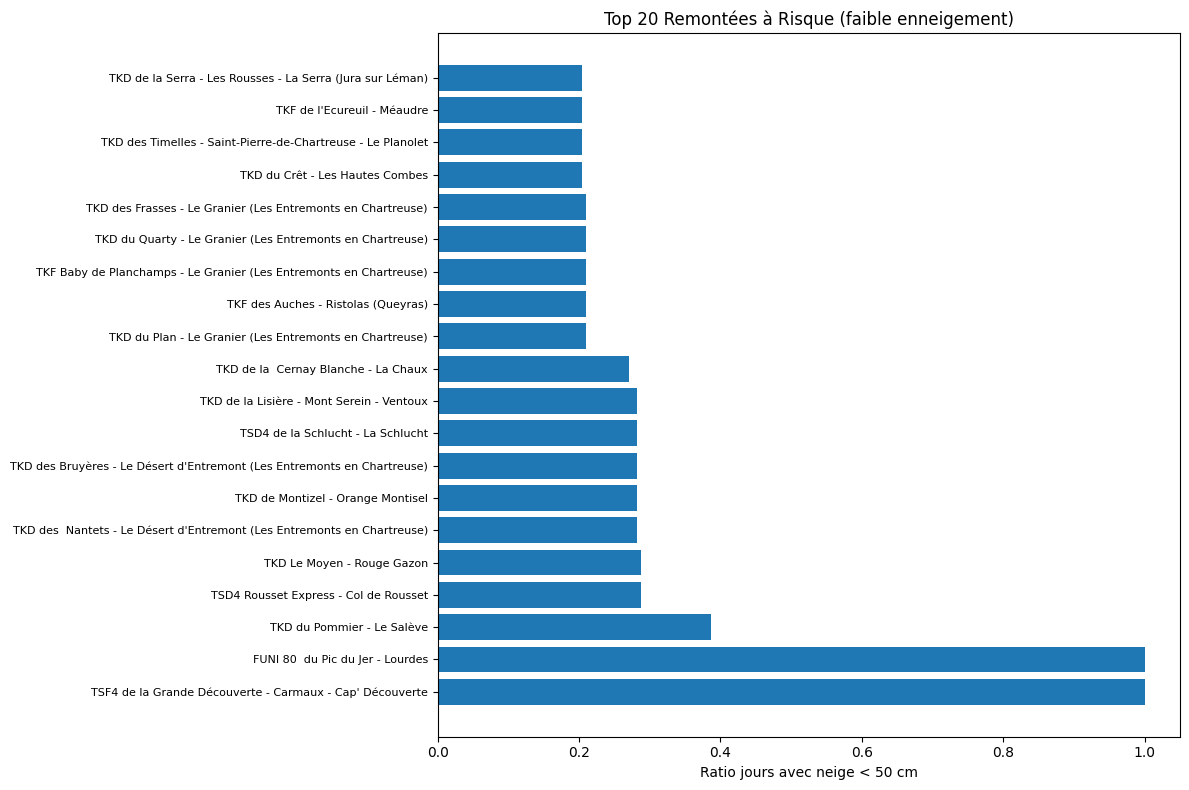


📊 STATISTIQUES FINALES
Total remontées analysées: 796
Période d'analyse: Row(min(date)='2024-11-01', max(date)='2025-04-30')
Remontées à risque élevé (>50% jours < 50cm): 2
Remontées avec périodes de sécheresse: 796

🛑 Arrêt de Spark...
✅ Analyse terminée !


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType, MapType, ArrayType
from pyspark.sql.functions import col, explode, to_date, avg, count, when, sum, max, min, regexp_replace, lag, desc, coalesce
from pyspark.sql.window import Window

# ========================================
# INITIALISATION DE SPARK
# ========================================
spark = SparkSession.builder \
    .appName("AnalyseNeigeRemontees") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "20") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "2g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .master("local[2]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark est prêt !")
print(f"📊 Version Spark: {spark.version}")
print(f"📦 Version Hadoop: {spark.sparkContext._jvm.org.apache.hadoop.util.VersionInfo.getVersion()}")

# ========================================
# CHARGEMENT DES DONNÉES
# ========================================
print("\n🔄 Chargement des données")

df_mecaniques = spark.read.option("multiline", "true").json("remontees_mecaniques.json")
df_neige = spark.read.option("multiline", "true").json("remontees_avec_neige.json")

print(f"✅ Remontées mécaniques: {df_mecaniques.count()} lignes")
print(f"✅ Données neige: {df_neige.count()} stations")

print("\n🔍 Structure des données:")
print("Remontées mécaniques:")
df_mecaniques.printSchema()
print("\nDonnées neige:")
df_neige.printSchema()

# ========================================
# NETTOYAGE DES REMONTÉES MÉCANIQUES
# ========================================
print("\n🧹 Nettoyage des remontées mécaniques")

from pyspark.sql.functions import regexp_replace, col, when, expr, length

if "nom" in df_mecaniques.columns:
    df_mecaniques = df_mecaniques.withColumn("appareil", coalesce(col("nom"), col("appareil")))
elif "appareil" not in df_mecaniques.columns:
    print("⚠️  ATTENTION: Ni 'nom' ni 'appareil' trouvé dans les données!")
    df_mecaniques.show(5)

print("   Exemples d'altitudes brutes:")
df_mecaniques.select("appareil", "station", "altitude_aval", "altitude_amont").show(5, truncate=False)

df_mecaniques = df_mecaniques.withColumn(
    "altitude_aval_int",
    expr("try_cast(regexp_replace(regexp_replace(altitude_aval, ' m', ''), 'm', '') as int)")
).withColumn(
    "altitude_amont_int",
    expr("try_cast(regexp_replace(regexp_replace(altitude_amont, ' m', ''), 'm', '') as int)")
)

df_mecaniques = df_mecaniques.withColumn(
    "altitude_aval_int",
    when(
        (col("altitude_aval_int").isNotNull()) & 
        (col("altitude_aval_int") > 0) & 
        (col("altitude_aval_int") < 5000),
        col("altitude_aval_int")
    ).otherwise(None)
).withColumn(
    "altitude_amont_int",
    when(
        (col("altitude_amont_int").isNotNull()) & 
        (col("altitude_amont_int") > 0) & 
        (col("altitude_amont_int") < 5000),
        col("altitude_amont_int")
    ).otherwise(None)
)

df_mecaniques = df_mecaniques.withColumn(
    "altitude_moyenne",
    when(
        col("altitude_aval_int").isNotNull() & col("altitude_amont_int").isNotNull(),
        (col("altitude_aval_int") + col("altitude_amont_int")) / 2
    ).otherwise(None)
)

df_mecaniques_in_service = df_mecaniques.filter(
    ((col("en_service") == True) | (col("en_service") == "true")) &
    col("altitude_moyenne").isNotNull()
)

print(f" Remontées en service avec altitude valide: {df_mecaniques_in_service.count()}")

print("\n   Exemples après nettoyage:")
df_mecaniques_in_service.select(
    "appareil", 
    "station",
    "altitude_aval", 
    "altitude_aval_int",
    "altitude_amont",
    "altitude_amont_int",
    "altitude_moyenne"
).show(10, truncate=False)

stats = df_mecaniques_in_service.select(
    min("altitude_moyenne").alias("min_alt"),
    avg("altitude_moyenne").alias("moy_alt"),
    max("altitude_moyenne").alias("max_alt")
).collect()[0]

print(f"\n   Altitudes: Min={stats['min_alt']:.0f}m, Moy={stats['moy_alt']:.0f}m, Max={stats['max_alt']:.0f}m")

# Compter combien ont été rejetées
nb_total = df_mecaniques.filter((col("en_service") == True) | (col("en_service") == "true")).count()
nb_rejetees = nb_total - df_mecaniques_in_service.count()
print(f"   {nb_rejetees} remontées rejetées pour altitude invalide")

# ========================================
# TRAITEMENT DES DONNÉES DE NEIGE
# ========================================
print("\n  Traitement des données de neige")

df_neige_exploded = df_neige.select(
    col("station"),
    col("coordonnees_moyennes"),
    explode("historique_neige").alias("record")
).select(
    col("station"),
    col("coordonnees_moyennes"),
    col("record.date").alias("date"),
    col("record.snowfall_cm").alias("neige_cm")
).filter(col("neige_cm").isNotNull())

print(f"   Total de mesures brutes: {df_neige_exploded.count()}")

print("\n   Calcul de l'enneigement cumulé")

window_cumul = Window.partitionBy("station").orderBy("date").rowsBetween(Window.unboundedPreceding, 0)

df_neige_cumul = df_neige_exploded.withColumn(
    "neige_cumulative_cm",
    sum(col("neige_cm")).over(window_cumul)
)

df_neige_daily = df_neige_cumul.groupBy("station", "date").agg(
    avg("neige_cumulative_cm").alias("neige_cm_moy"),
    max("neige_cumulative_cm").alias("neige_cm_max"),
    min("neige_cumulative_cm").alias("neige_cm_min"),
    count("*").alias("nb_mesures_jour")
)

df_neige_clean = df_neige_daily.select(
    "station", 
    "date", 
    col("neige_cm_moy").alias("neige_cm")
)

print(f"   Jours uniques avec mesures: {df_neige_clean.count()}")
print("\n   Statistiques de neige (en cm cumulé):")
stats = df_neige_clean.select(
    min("neige_cm").alias("min_cm"),
    avg("neige_cm").alias("moy_cm"),
    max("neige_cm").alias("max_cm")
).collect()[0]

print(f"   Min: {stats['min_cm']:.2f} cm")
print(f"   Moyenne: {stats['moy_cm']:.2f} cm")
print(f"   Max: {stats['max_cm']:.2f} cm")

# Vérifier la distribution
print("\n   Exemples de données nettoyées:")
df_neige_clean.orderBy("station", "date").show(10)

# ========================================
# JOINTURE DES DONNÉES
# ========================================
print("\nJointure des données")

df_combine = df_mecaniques_in_service.alias("mec").join(
    df_neige_clean.alias("neige"),
    col("mec.station") == col("neige.station"),
    "inner"
).select(
    col("mec.appareil"),
    col("mec.station"),
    col("mec.altitude_moyenne"),
    col("mec.altitude_aval_int"),
    col("mec.altitude_amont_int"),
    col("neige.date"),
    col("neige.neige_cm")
)

print(f"   Données combinées: {df_combine.count()} lignes")
print(f"   Remontées avec données: {df_combine.select('appareil', 'station').distinct().count()}")

# Afficher quelques exemples
print("\n   Exemples de données combinées:")
df_combine.orderBy("station", "date").show(10)

# ========================================
# ANALYSES
# ========================================
print("\nAnalyses des risques")

df_moyenne = df_combine.groupBy("appareil", "station").agg(
    avg("neige_cm").alias("neige_moyenne_cm"),
    min("neige_cm").alias("neige_min_cm"),
    max("neige_cm").alias("neige_max_cm"),
    count("*").alias("nb_jours_mesure"),
    avg("altitude_moyenne").alias("altitude_moyenne")
)

print("\n=== Top 10 remontées avec le PLUS de neige ===")
df_moyenne.orderBy(desc("neige_moyenne_cm")).show(10, truncate=False)

print("\n=== Top 10 remontées avec le MOINS de neige ===")
df_moyenne.orderBy("neige_moyenne_cm").show(10, truncate=False)

df_risque = df_combine.groupBy("appareil", "station").agg(
    (count(when(col("neige_cm") < 50, True)) / count("*")).alias("ratio_jours_faible_neige"),
    count(when(col("neige_cm") < 50, True)).alias("jours_neige_faible"),
    count(when(col("neige_cm") < 30, True)).alias("jours_neige_critique"),
    count("*").alias("jours_total")
)

print("\n=== Top 10 remontées à RISQUE (< 50 cm) ===")
df_risque.orderBy(desc("ratio_jours_faible_neige")).show(10, truncate=False)

print("\nDétection des périodes de sécheresse")

window_sec = Window.partitionBy("appareil", "station").orderBy("date")

df_periode = df_combine.withColumn(
    "neige_insuffisante", 
    when(col("neige_cm") < 50, 1).otherwise(0)
)

df_periode = df_periode.withColumn(
    "changement",
    when(
        col("neige_insuffisante") != lag("neige_insuffisante", 1, 0).over(window_sec), 
        1
    ).otherwise(0)
)

df_periode = df_periode.withColumn(
    "groupe",
    sum("changement").over(window_sec.rowsBetween(Window.unboundedPreceding, 0))
)

df_secheresse = df_periode.filter(col("neige_insuffisante") == 1) \
    .groupBy("appareil", "station", "groupe").agg(
        count("*").alias("duree_jours"),
        min("date").alias("debut_periode"),
        max("date").alias("fin_periode"),
        avg("neige_cm").alias("neige_moy_periode")
    ).filter(col("duree_jours") >= 7)

print(f"\n   Total périodes détectées: {df_secheresse.count()}")
print("\n=== Top 10 périodes de sécheresse les plus longues ===")
df_secheresse.orderBy(desc("duree_jours")).show(10, truncate=False)

df_secheresse_agg = df_secheresse.groupBy("appareil", "station").agg(
    count("*").alias("nombre_periodes_secheresse"),
    max("duree_jours").alias("duree_max_secheresse"),
    avg("duree_jours").alias("duree_moyenne_secheresse")
)

print("\n=== Remontées avec le plus de périodes de sécheresse ===")
df_secheresse_agg.orderBy(desc("nombre_periodes_secheresse")).show(10, truncate=False)

# ========================================
# RÉSULTATS FINAUX
# ========================================
print("\nCompilation des résultats finaux")

df_remontees_risque = df_risque \
    .join(df_moyenne, ["appareil", "station"]) \
    .join(df_secheresse_agg, ["appareil", "station"], "left") \
    .fillna(0, subset=["nombre_periodes_secheresse", "duree_max_secheresse", "duree_moyenne_secheresse"])

print("\n" + "="*80)
print("TOP 20 REMONTÉES À RISQUE")
print("="*80)
df_remontees_risque.select(
    "appareil",
    "station", 
    "ratio_jours_faible_neige",
    "neige_moyenne_cm",
    "altitude_moyenne",
    "nombre_periodes_secheresse"
).orderBy(desc("ratio_jours_faible_neige")).show(20, truncate=False)

# ========================================
# SAUVEGARDE
# ========================================
print("\nSauvegarde des résultats")

df_remontees_risque.toPandas().to_csv("data/remontees_a_risque.csv", index=False)
print("Sauvegarde réussie avec Pandas")

# ========================================
# VISUALISATION
# ========================================
print("\n📈 Création de la visualisation")

try:
    import matplotlib.pyplot as plt
    
    df_visu = df_remontees_risque.orderBy(desc("ratio_jours_faible_neige")).limit(20).toPandas()
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(df_visu)), df_visu["ratio_jours_faible_neige"])
    plt.yticks(range(len(df_visu)), df_visu["appareil"] + " - " + df_visu["station"], fontsize=8)
    plt.xlabel("Ratio jours avec neige < 50 cm")
    plt.title("Top 20 Remontées à Risque (faible enneigement)")
    plt.tight_layout()
    plt.savefig("data/remontees_risque_visualisation.png", dpi=150, bbox_inches='tight')
    print("Graphique sauvegardé: data/remontees_risque_visualisation.png")
    plt.show()
    
except Exception as e:
    print(f"⚠️  Impossible de créer la visualisation: {e}")

# ========================================
# STATISTIQUES FINALES
# ========================================
print("\n" + "="*80)
print("=== STATISTIQUES FINALES ===")
print("="*80)
print(f"Total remontées analysées: {df_remontees_risque.count()}")
print(f"Période d'analyse: {df_combine.agg(min('date'), max('date')).collect()[0]}")
print(f"Remontées à risque élevé (>50% jours < 50cm): {df_remontees_risque.filter(col('ratio_jours_faible_neige') > 0.5).count()}")
print(f"Remontées avec périodes de sécheresse: {df_remontees_risque.filter(col('nombre_periodes_secheresse') > 0).count()}")
print("="*80)

spark.stop()